<a href="https://colab.research.google.com/github/swarnojjwal/Lab-Activities-/blob/main/GNN_Colab_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torch-geometric -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import random
import csv
import pandas as pd

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.utils import dropout_edge, degree

# -----------------------
# Device
# -----------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# -----------------------
# Seed
# -----------------------
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# -----------------------
# Models
# -----------------------
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden, heads=8)
        self.conv2 = GATConv(hidden * 8, out_channels, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


class SAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# -----------------------
# Perturbations (correct)
# -----------------------
def random_removal(edge_index, p):
    new_edge_index, _ = dropout_edge(edge_index, p=p)
    return new_edge_index


def degree_aware_removal(edge_index, num_nodes, p):
    deg = degree(edge_index[0], num_nodes=num_nodes)
    threshold = torch.quantile(deg, 0.8)  # top 20% hubs

    src, dst = edge_index
    candidate_mask = (deg[src] >= threshold) | (deg[dst] >= threshold)

    candidate_edges = edge_index[:, candidate_mask]
    kept_candidate, _ = dropout_edge(candidate_edges, p=p)

    non_candidate_edges = edge_index[:, ~candidate_mask]

    return torch.cat([kept_candidate, non_candidate_edges], dim=1)


def class_aware_removal(edge_index, y, p):
    src, dst = edge_index
    candidate_mask = (y[src] != y[dst])

    candidate_edges = edge_index[:, candidate_mask]
    kept_candidate, _ = dropout_edge(candidate_edges, p=p)

    non_candidate_edges = edge_index[:, ~candidate_mask]

    return torch.cat([kept_candidate, non_candidate_edges], dim=1)

# -----------------------
# Metrics
# -----------------------
def accuracy(pred, y, mask):
    return (pred[mask] == y[mask]).sum().item() / mask.sum().item()

def stability(pred_clean, pred_pert, mask):
    return (pred_clean[mask] == pred_pert[mask]).sum().item() / mask.sum().item()

# -----------------------
# Train & Predict
# -----------------------
def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

def get_pred(model, data, edge_index):
    model.eval()
    out = model(data.x, edge_index)
    return out.argmax(dim=1)

# -----------------------
# Main Experiment
# -----------------------
datasets = ["Cora", "CiteSeer", "PubMed"]
models = {"GCN": GCN, "GAT": GAT, "SAGE": SAGE}
perturbations = ["random", "degree", "class"]
levels = [0.1, 0.2, 0.4]
seeds = [0,1,2,3,4]

with open("results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["dataset","model","perturbation","p","seed","accuracy","stability"])

    for dname in datasets:
        print(f"\nDataset: {dname}")
        dataset = Planetoid(root=f"/tmp/{dname}", name=dname)
        data = dataset[0].to(device)

        for mname, M in models.items():
            print(f" Model: {mname}")
            for seed in seeds:
                set_seed(seed)

                model = M(dataset.num_features, 16, dataset.num_classes).to(device)
                optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

                best_val = 0
                best_state = None

                for epoch in range(200):
                    train(model, data, optimizer)
                    pred = get_pred(model, data, data.edge_index)
                    val_acc = accuracy(pred, data.y, data.val_mask)
                    if val_acc > best_val:
                        best_val = val_acc
                        best_state = model.state_dict()

                model.load_state_dict(best_state)

                clean_pred = get_pred(model, data, data.edge_index)

                for p in levels:
                    for pert in perturbations:
                        if pert == "random":
                            pe = random_removal(data.edge_index, p)
                        elif pert == "degree":
                            pe = degree_aware_removal(data.edge_index, data.num_nodes, p)
                        else:
                            pe = class_aware_removal(data.edge_index, data.y, p)

                        pert_pred = get_pred(model, data, pe)
                        acc = accuracy(pert_pred, data.y, data.test_mask)
                        stab = stability(clean_pred, pert_pred, data.test_mask)

                        writer.writerow([dname,mname,pert,p,seed,acc,stab])

                        print(f"  {pert} p={p} | Acc={acc:.4f} | Stab={stab:.4f}")

print("\nDone. Results saved to results.csv")


Using device: cuda

Dataset: Cora


Processing...
Done!


 Model: GCN
  random p=0.1 | Acc=0.8030 | Stab=0.9650
  degree p=0.1 | Acc=0.8080 | Stab=0.9770
  class p=0.1 | Acc=0.8070 | Stab=0.9850
  random p=0.2 | Acc=0.7960 | Stab=0.9360
  degree p=0.2 | Acc=0.8020 | Stab=0.9570
  class p=0.2 | Acc=0.8120 | Stab=0.9790
  random p=0.4 | Acc=0.7690 | Stab=0.8690
  degree p=0.4 | Acc=0.7830 | Stab=0.9280
  class p=0.4 | Acc=0.8180 | Stab=0.9600
  random p=0.1 | Acc=0.7990 | Stab=0.9680
  degree p=0.1 | Acc=0.7980 | Stab=0.9760
  class p=0.1 | Acc=0.8060 | Stab=0.9820
  random p=0.2 | Acc=0.7830 | Stab=0.9440
  degree p=0.2 | Acc=0.7900 | Stab=0.9590
  class p=0.2 | Acc=0.8050 | Stab=0.9790
  random p=0.4 | Acc=0.7750 | Stab=0.8930
  degree p=0.4 | Acc=0.7730 | Stab=0.9150
  class p=0.4 | Acc=0.8110 | Stab=0.9680
  random p=0.1 | Acc=0.7950 | Stab=0.9520
  degree p=0.1 | Acc=0.8030 | Stab=0.9790
  class p=0.1 | Acc=0.8070 | Stab=0.9860
  random p=0.2 | Acc=0.7910 | Stab=0.9300
  degree p=0.2 | Acc=0.7950 | Stab=0.9550
  class p=0.2 | Acc=0.8080 | 

Processing...
Done!


 Model: GCN
  random p=0.1 | Acc=0.6800 | Stab=0.9620
  degree p=0.1 | Acc=0.6810 | Stab=0.9800
  class p=0.1 | Acc=0.6840 | Stab=0.9850
  random p=0.2 | Acc=0.6630 | Stab=0.9460
  degree p=0.2 | Acc=0.6820 | Stab=0.9700
  class p=0.2 | Acc=0.6910 | Stab=0.9620
  random p=0.4 | Acc=0.6660 | Stab=0.8880
  degree p=0.4 | Acc=0.6840 | Stab=0.9490
  class p=0.4 | Acc=0.6840 | Stab=0.9530
  random p=0.1 | Acc=0.6840 | Stab=0.9610
  degree p=0.1 | Acc=0.6840 | Stab=0.9920
  class p=0.1 | Acc=0.6870 | Stab=0.9870
  random p=0.2 | Acc=0.6620 | Stab=0.9380
  degree p=0.2 | Acc=0.6780 | Stab=0.9730
  class p=0.2 | Acc=0.6840 | Stab=0.9680
  random p=0.4 | Acc=0.6430 | Stab=0.8640
  degree p=0.4 | Acc=0.6690 | Stab=0.9420
  class p=0.4 | Acc=0.6830 | Stab=0.9570
  random p=0.1 | Acc=0.6740 | Stab=0.9520
  degree p=0.1 | Acc=0.6820 | Stab=0.9810
  class p=0.1 | Acc=0.6870 | Stab=0.9820
  random p=0.2 | Acc=0.6680 | Stab=0.9310
  degree p=0.2 | Acc=0.6810 | Stab=0.9620
  class p=0.2 | Acc=0.6820 | 

Processing...
Done!


 Model: GCN
  random p=0.1 | Acc=0.7760 | Stab=0.9690
  degree p=0.1 | Acc=0.7860 | Stab=0.9700
  class p=0.1 | Acc=0.7860 | Stab=0.9930
  random p=0.2 | Acc=0.7840 | Stab=0.9570
  degree p=0.2 | Acc=0.7770 | Stab=0.9570
  class p=0.2 | Acc=0.7920 | Stab=0.9840
  random p=0.4 | Acc=0.7670 | Stab=0.9210
  degree p=0.4 | Acc=0.7740 | Stab=0.9150
  class p=0.4 | Acc=0.7930 | Stab=0.9700
  random p=0.1 | Acc=0.7790 | Stab=0.9740
  degree p=0.1 | Acc=0.7870 | Stab=0.9780
  class p=0.1 | Acc=0.7950 | Stab=0.9870
  random p=0.2 | Acc=0.7780 | Stab=0.9630
  degree p=0.2 | Acc=0.7800 | Stab=0.9520
  class p=0.2 | Acc=0.7920 | Stab=0.9770
  random p=0.4 | Acc=0.7790 | Stab=0.9310
  degree p=0.4 | Acc=0.7660 | Stab=0.9340
  class p=0.4 | Acc=0.8040 | Stab=0.9650
  random p=0.1 | Acc=0.7840 | Stab=0.9780
  degree p=0.1 | Acc=0.7820 | Stab=0.9680
  class p=0.1 | Acc=0.7810 | Stab=0.9920
  random p=0.2 | Acc=0.7700 | Stab=0.9550
  degree p=0.2 | Acc=0.7790 | Stab=0.9570
  class p=0.2 | Acc=0.7840 | 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

grouped = df.groupby(["dataset","model","perturbation","p"]).agg(
    acc_mean=("accuracy","mean"),
    acc_std=("accuracy","std"),
    stab_mean=("stability","mean"),
    stab_std=("stability","std"),
).reset_index()


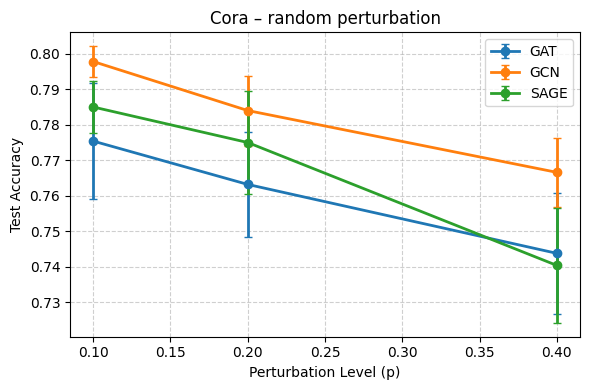

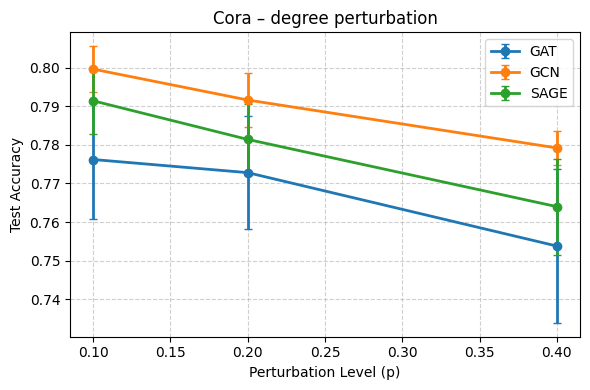

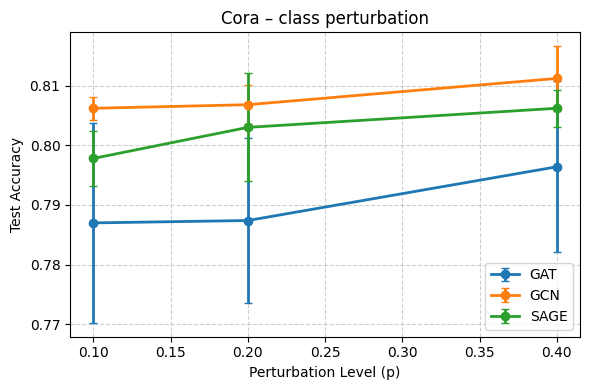

In [4]:
def plot_accuracy(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["acc_mean"], yerr=data_m["acc_std"],
            marker="o", linewidth=2, capsize=3, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Test Accuracy")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_accuracy("Cora", "random")
plot_accuracy("Cora", "degree")
plot_accuracy("Cora", "class")
#2


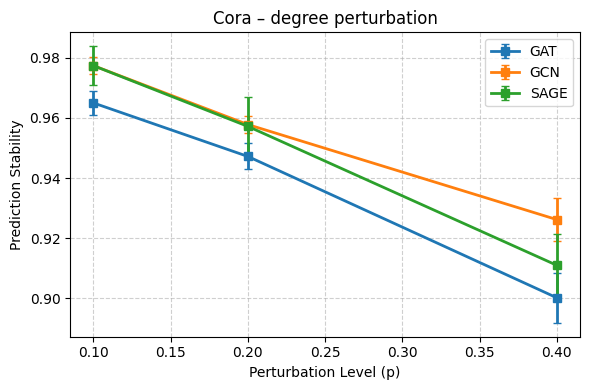

In [5]:
def plot_stability(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["stab_mean"], yerr=data_m["stab_std"],
            marker="s", linewidth=2, capsize=3, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Prediction Stability")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_stability("Cora", "degree")
#3


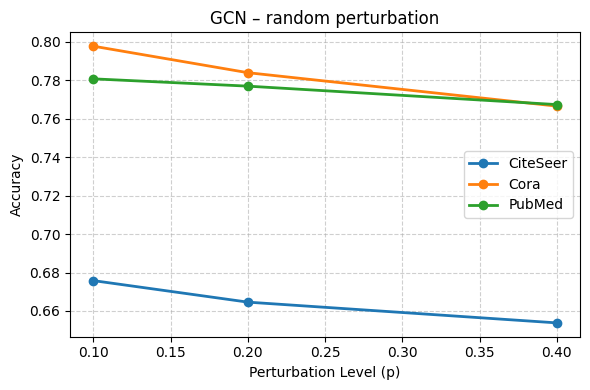

In [6]:
def plot_model_across_datasets(model_name, perturbation_type):
    subset = grouped[
        (grouped["model"] == model_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for dataset in subset["dataset"].unique():
        data_d = subset[subset["dataset"] == dataset]
        plt.plot(data_d["p"], data_d["acc_mean"], marker="o", linewidth=2, label=dataset)

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_model_across_datasets("GCN", "random")


In [7]:
plt.savefig("figure1.pdf", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

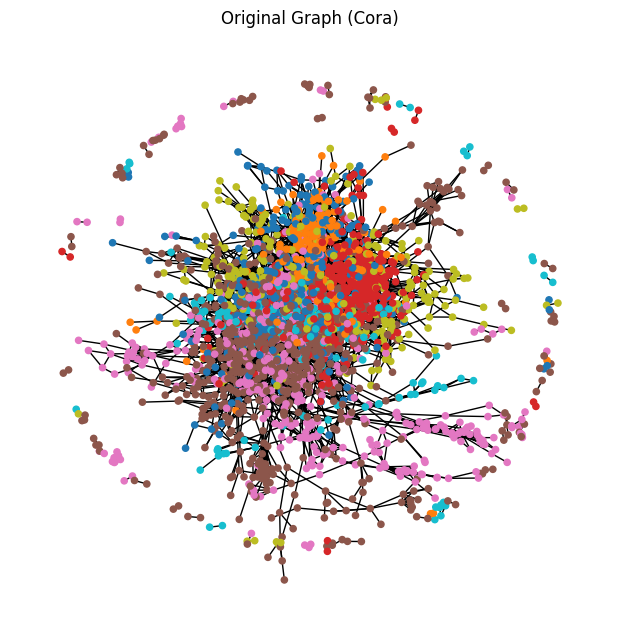

In [8]:
import networkx as nx
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

dataset = Planetoid(root="/tmp/Cora", name="Cora")
data = dataset[0]

G_clean = to_networkx(data, to_undirected=True)

plt.figure(figsize=(6,6))
nx.draw(G_clean, node_size=20, node_color=data.y.numpy(), cmap="tab10")
plt.title("Original Graph (Cora)")
plt.show()
# fig 1

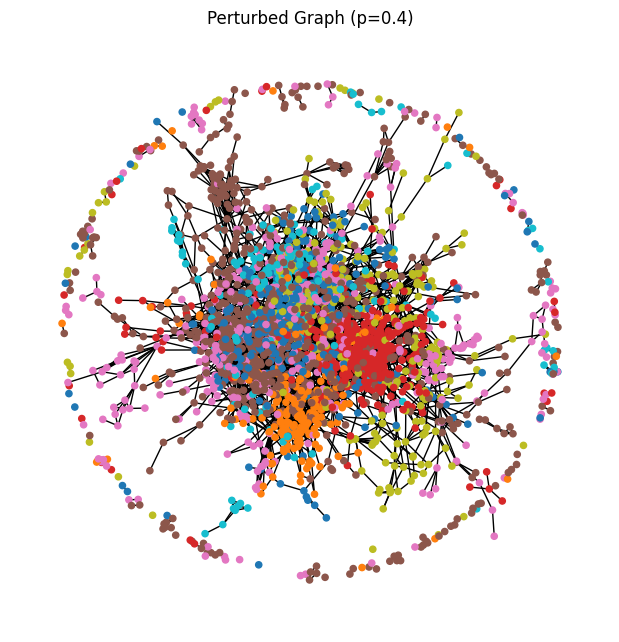

In [9]:
from torch_geometric.utils import dropout_edge

edge_index_pert, _ = dropout_edge(data.edge_index, p=0.4)
data_pert = data.clone()
data_pert.edge_index = edge_index_pert

G_pert = to_networkx(data_pert, to_undirected=True)

plt.figure(figsize=(6,6))
nx.draw(G_pert, node_size=20, node_color=data.y.numpy(), cmap="tab10")
plt.title("Perturbed Graph (p=0.4)")
plt.show()


In [10]:
from google.colab import files
files.download("results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd

df = pd.read_csv("results.csv")

grouped = df.groupby(["dataset", "model", "perturbation", "p"]).agg(
    acc_mean=("accuracy", "mean"),
    acc_std=("accuracy", "std"),
    stab_mean=("stability", "mean"),
    stab_std=("stability", "std"),
).reset_index()

grouped


,dataset,model,perturbation,p,acc_mean,acc_std,stab_mean,stab_std
0,CiteSeer,GAT,class,0.1,0.6670,0.017146,0.9836,0.005367
1,CiteSeer,GAT,class,0.2,0.6686,0.017487,0.9706,0.005595
2,CiteSeer,GAT,class,0.4,0.6720,0.014036,0.9452,0.010663
3,CiteSeer,GAT,degree,0.1,0.6632,0.020945,0.9762,0.001789
4,CiteSeer,GAT,degree,0.2,0.6576,0.020720,0.9610,0.008775
...,...,...,...,...,...,...,...,...
76,PubMed,SAGE,degree,0.2,0.7660,0.004000,0.9594,0.006148
77,PubMed,SAGE,degree,0.4,0.7598,0.005541,0.9268,0.010964
78,PubMed,SAGE,random,0.1,0.7656,0.006877,0.9756,0.004615
79,PubMed,SAGE,random,0.2,0.7590,0.005523,0.9570,0.007746


In [12]:
def make_latex_table(df, dataset_name, perturbation_type):
    sub = df[
        (df["dataset"] == dataset_name) &
        (df["perturbation"] == perturbation_type)
    ]

    pivot = sub.pivot(index="model", columns="p", values=["acc_mean", "acc_std"])

    print("\\begin{table}[t]")
    print("\\centering")
    print(f"\\caption{{Accuracy (mean $\\pm$ std) on {dataset_name} under {perturbation_type} perturbation.}}")
    print("\\begin{tabular}{l" + "c"*len(pivot.columns.levels[1]) + "}")
    print("\\hline")

    header = "Model"
    for p in pivot.columns.levels[1]:
        header += f" & p={p}"
    print(header + " \\\\")
    print("\\hline")

    for model in pivot.index:
        row = model
        for p in pivot.columns.levels[1]:
            mean = pivot.loc[model, ("acc_mean", p)]
            std = pivot.loc[model, ("acc_std", p)]
            row += f" & {mean:.3f} $\\pm$ {std:.3f}"
        print(row + " \\\\")

    print("\\hline")
    print("\\end{tabular}")
    print("\\end{table}")

make_latex_table(grouped, "Cora", "random")


\begin{table}[t]
\centering
\caption{Accuracy (mean $\pm$ std) on Cora under random perturbation.}
\begin{tabular}{lccc}
\hline
Model & p=0.1 & p=0.2 & p=0.4 \\
\hline
GAT & 0.775 $\pm$ 0.016 & 0.763 $\pm$ 0.015 & 0.744 $\pm$ 0.017 \\
GCN & 0.798 $\pm$ 0.004 & 0.784 $\pm$ 0.010 & 0.767 $\pm$ 0.010 \\
SAGE & 0.785 $\pm$ 0.007 & 0.775 $\pm$ 0.014 & 0.740 $\pm$ 0.016 \\
\hline
\end{tabular}
\end{table}


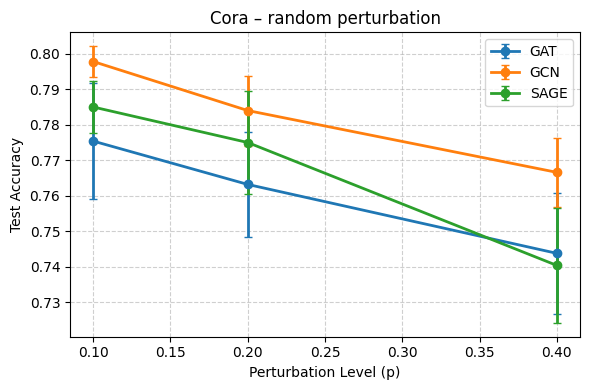

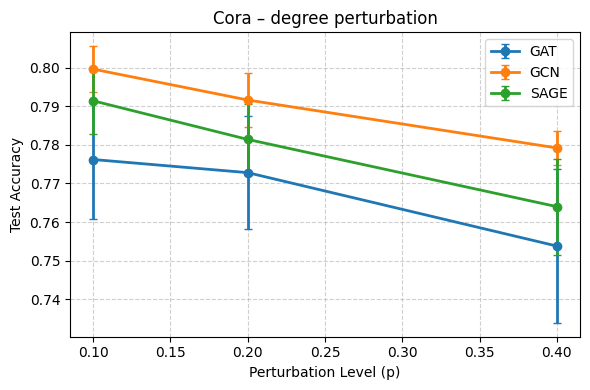

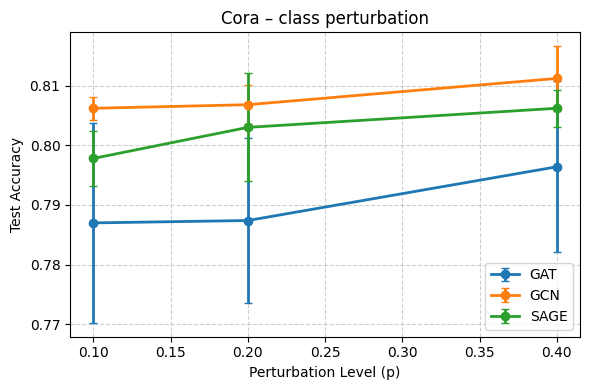

In [13]:
import matplotlib.pyplot as plt

def plot_accuracy(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["acc_mean"], yerr=data_m["acc_std"],
            marker="o", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Test Accuracy")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_accuracy("Cora", "random")
plot_accuracy("Cora", "degree")
plot_accuracy("Cora", "class")


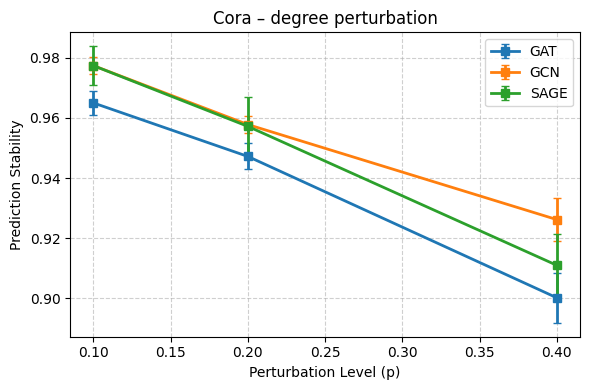

In [14]:
def plot_stability(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["stab_mean"], yerr=data_m["stab_std"],
            marker="s", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Prediction Stability")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_stability("Cora", "degree")


In [15]:
df_gcn = df[df["model"] == "GCN"]
df_gcn.head()


,dataset,model,perturbation,p,seed,accuracy,stability
0,Cora,GCN,random,0.1,0,0.803,0.965
1,Cora,GCN,degree,0.1,0,0.808,0.977
2,Cora,GCN,class,0.1,0,0.807,0.985
3,Cora,GCN,random,0.2,0,0.796,0.936
4,Cora,GCN,degree,0.2,0,0.802,0.957


In [16]:
df_cora = df[df["dataset"] == "Cora"]
df_cora.head()


,dataset,model,perturbation,p,seed,accuracy,stability
0,Cora,GCN,random,0.1,0,0.803,0.965
1,Cora,GCN,degree,0.1,0,0.808,0.977
2,Cora,GCN,class,0.1,0,0.807,0.985
3,Cora,GCN,random,0.2,0,0.796,0.936
4,Cora,GCN,degree,0.2,0,0.802,0.957


In [17]:
df_random = df[df["perturbation"] == "random"]
df_random.head()


,dataset,model,perturbation,p,seed,accuracy,stability
0,Cora,GCN,random,0.1,0,0.803,0.965
3,Cora,GCN,random,0.2,0,0.796,0.936
6,Cora,GCN,random,0.4,0,0.769,0.869
9,Cora,GCN,random,0.1,1,0.799,0.968
12,Cora,GCN,random,0.2,1,0.783,0.944


In [18]:
df_sub = df[
    (df["dataset"] == "Cora") &
    (df["model"] == "GAT") &
    (df["perturbation"] == "degree")
]
df_sub


,dataset,model,perturbation,p,seed,accuracy,stability
46,Cora,GAT,degree,0.1,0,0.792,0.966
49,Cora,GAT,degree,0.2,0,0.785,0.950
52,Cora,GAT,degree,0.4,0,0.781,0.912
55,Cora,GAT,degree,0.1,1,0.752,0.962
58,Cora,GAT,degree,0.2,1,0.749,0.942
61,Cora,GAT,degree,0.4,1,0.730,0.903
64,Cora,GAT,degree,0.1,2,0.773,0.969
67,Cora,GAT,degree,0.2,2,0.769,0.945
70,Cora,GAT,degree,0.4,2,0.740,0.895
73,Cora,GAT,degree,0.1,3,0.778,0.960


In [19]:
import torch
import pandas as pd
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import degree

# Load dataset
dataset = Planetoid(root="/tmp/Cora", name="Cora")
data = dataset[0]

deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
deg = deg.cpu().numpy()


In [20]:
import numpy as np

threshold = np.median(deg)
low_nodes = deg < threshold
high_nodes = deg >= threshold

print("Low-degree nodes:", low_nodes.sum())
print("High-degree nodes:", high_nodes.sum())


Low-degree nodes: 1068
High-degree nodes: 1640



Training GCN...
GCN | p=0.1 | drop low=0.0125, drop high=0.0083
GCN | p=0.2 | drop low=0.0275, drop high=0.0133
GCN | p=0.4 | drop low=0.0675, drop high=0.0500

Training GAT...
GAT | p=0.1 | drop low=0.0200, drop high=0.0083
GAT | p=0.2 | drop low=0.0075, drop high=0.0067
GAT | p=0.4 | drop low=0.0300, drop high=0.0383

Training GraphSAGE...
GraphSAGE | p=0.1 | drop low=0.0125, drop high=0.0033
GraphSAGE | p=0.2 | drop low=0.0100, drop high=0.0100
GraphSAGE | p=0.4 | drop low=0.0400, drop high=0.0417


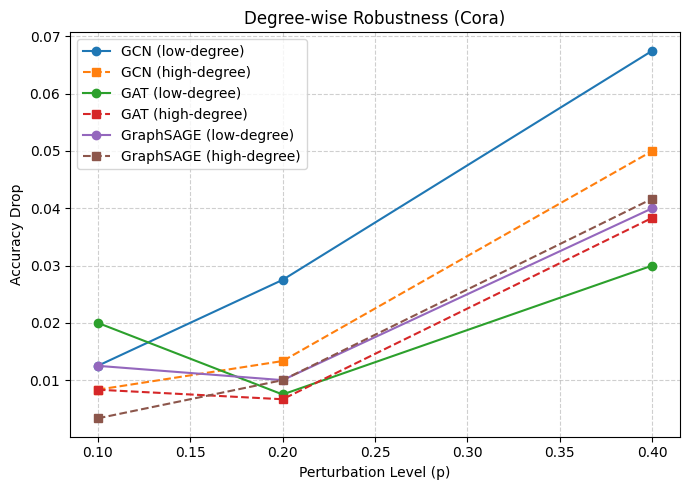

In [21]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch_geometric.utils import degree, dropout_edge

# --------------------
# Load dataset
# --------------------
dataset = Planetoid(root="/tmp/Cora", name="Cora")
data = dataset[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

# --------------------
# Models
# --------------------
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden, heads=8)
        self.conv2 = GATConv(hidden*8, out_channels, concat=False)
    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class SAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

models = {
    "GCN": GCN,
    "GAT": GAT,
    "GraphSAGE": SAGE
}

# --------------------
# Train function
# --------------------
def train_model(ModelClass):
    model = ModelClass(dataset.num_features, 16, dataset.num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_val = 0
    best_state = None
    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        pred = out.argmax(dim=1)
        val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
        if val_acc > best_val:
            best_val = val_acc
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model

# --------------------
# Degree groups
# --------------------
deg = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
threshold = np.median(deg)
low_nodes = deg < threshold
high_nodes = deg >= threshold

def group_accuracy(pred, y, test_mask, group_mask):
    mask = test_mask.cpu().numpy() & group_mask
    mask = torch.tensor(mask, device=pred.device)
    return (pred[mask] == y[mask]).sum().item() / mask.sum().item()

# --------------------
# Experiment
# --------------------
p_levels = [0.1, 0.2, 0.4]

plt.figure(figsize=(7,5))

for name, ModelClass in models.items():
    print(f"\nTraining {name}...")
    model = train_model(ModelClass)

    model.eval()
    clean_out = model(data.x, data.edge_index)
    clean_pred = clean_out.argmax(dim=1)

    drop_low_list = []
    drop_high_list = []

    for p in p_levels:
        edge_index_pert, _ = dropout_edge(data.edge_index, p=p)
        pert_out = model(data.x, edge_index_pert)
        pert_pred = pert_out.argmax(dim=1)

        acc_clean_low = group_accuracy(clean_pred, data.y, data.test_mask, low_nodes)
        acc_pert_low = group_accuracy(pert_pred, data.y, data.test_mask, low_nodes)

        acc_clean_high = group_accuracy(clean_pred, data.y, data.test_mask, high_nodes)
        acc_pert_high = group_accuracy(pert_pred, data.y, data.test_mask, high_nodes)

        drop_low_list.append(acc_clean_low - acc_pert_low)
        drop_high_list.append(acc_clean_high - acc_pert_high)

        print(f"{name} | p={p} | drop low={acc_clean_low-acc_pert_low:.4f}, drop high={acc_clean_high-acc_pert_high:.4f}")

    # Plot
    plt.plot(p_levels, drop_low_list, marker="o", label=f"{name} (low-degree)")
    plt.plot(p_levels, drop_high_list, marker="s", linestyle="--", label=f"{name} (high-degree)")

plt.xlabel("Perturbation Level (p)")
plt.ylabel("Accuracy Drop")
plt.title("Degree-wise Robustness (Cora)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
#4

Datasets found: ['CiteSeer' 'Cora' 'PubMed']
Perturbations found: ['class' 'degree' 'random']


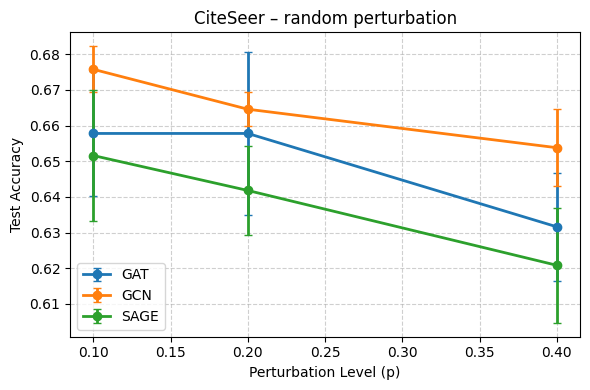

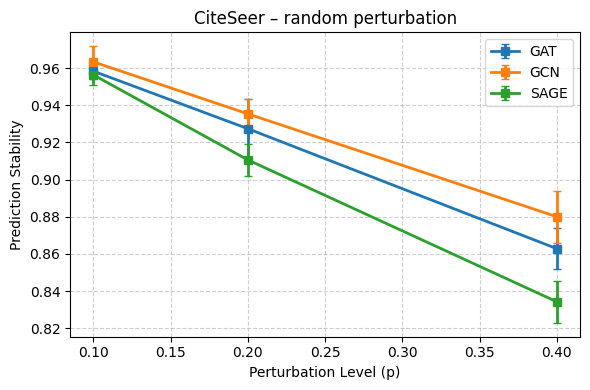

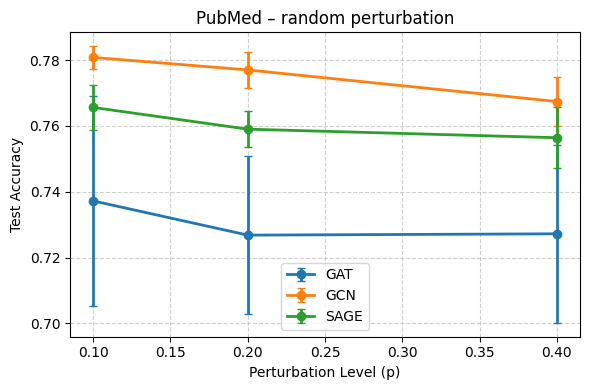

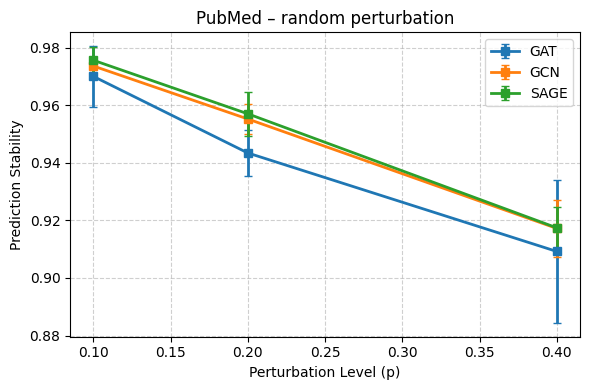

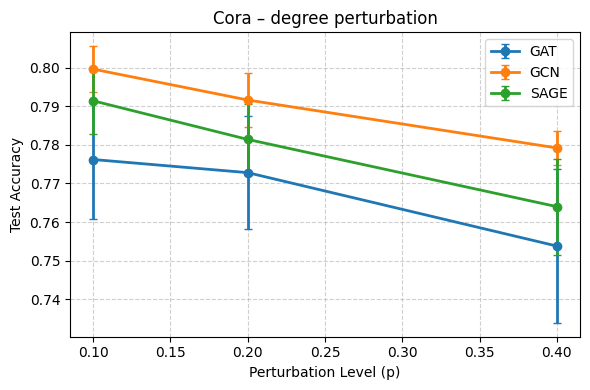

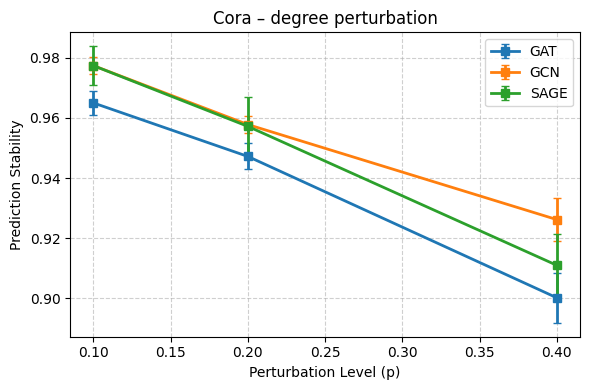

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# Load results.csv
# ------------------------
csv_path = "results.csv"   # change if needed
df = pd.read_csv(csv_path)

# ------------------------
# Compute mean ± std
# ------------------------
grouped = df.groupby(["dataset","model","perturbation","p"]).agg(
    acc_mean=("accuracy","mean"),
    acc_std=("accuracy","std"),
    stab_mean=("stability","mean"),
    stab_std=("stability","std")
).reset_index()

print("Datasets found:", grouped["dataset"].unique())
print("Perturbations found:", grouped["perturbation"].unique())

# ------------------------
# Plot Accuracy
# ------------------------
def plot_accuracy(dataset_name, perturbation_type, save=False):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["acc_mean"], yerr=data_m["acc_std"],
            marker="o", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Test Accuracy")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    if save:
        plt.savefig(f"accuracy_{dataset_name}_{perturbation_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------
# Plot Stability
# ------------------------
def plot_stability(dataset_name, perturbation_type, save=False):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["stab_mean"], yerr=data_m["stab_std"],
            marker="s", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Prediction Stability")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    if save:
        plt.savefig(f"stability_{dataset_name}_{perturbation_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------
# EXAMPLES (run these)
# ------------------------

# For CiteSeer (random)
plot_accuracy("CiteSeer", "random", save=True)
plot_stability("CiteSeer", "random", save=True)

# For PubMed (random)
plot_accuracy("PubMed", "random", save=True)
plot_stability("PubMed", "random", save=True)

# For Cora (degree-aware)
plot_accuracy("Cora", "degree", save=True)
plot_stability("Cora", "degree", save=True)


Datasets found: ['CiteSeer' 'Cora' 'PubMed']
Perturbations found: ['class' 'degree' 'random']
Generating plots for CiteSeer – random


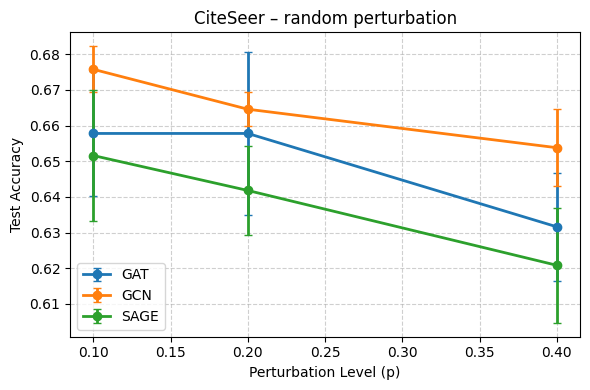

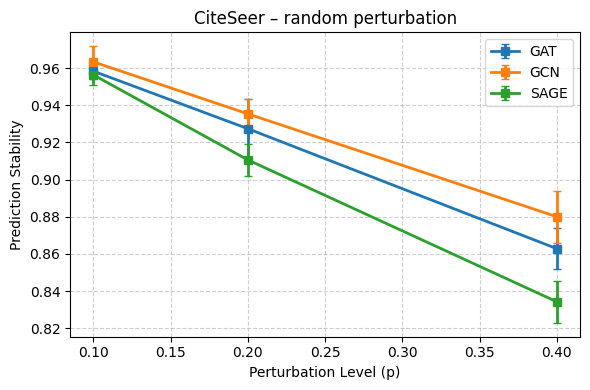

Generating plots for CiteSeer – degree


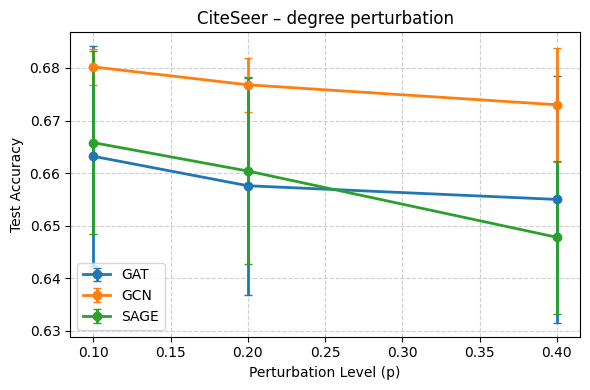

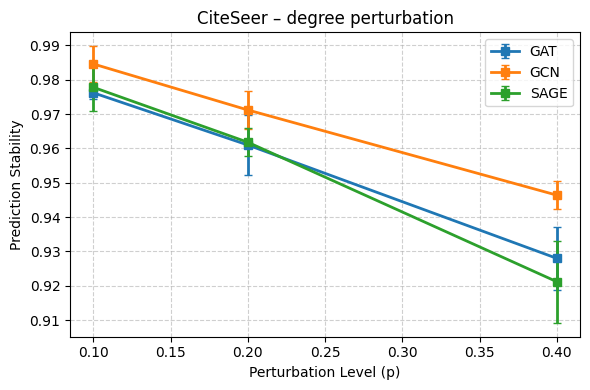

Generating plots for Cora – random


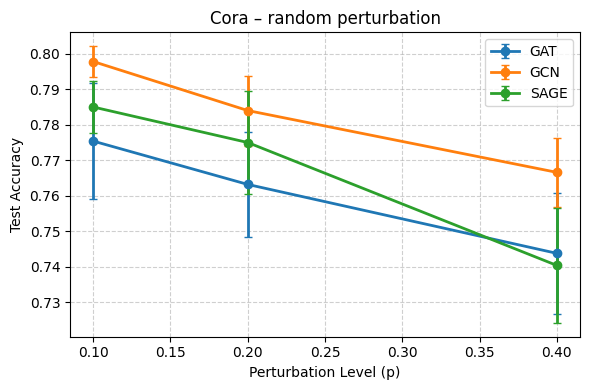

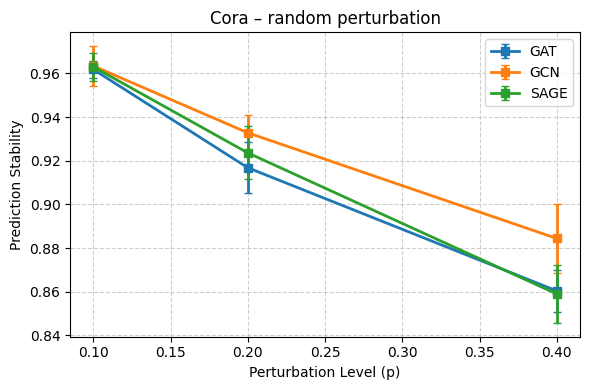

Generating plots for Cora – degree


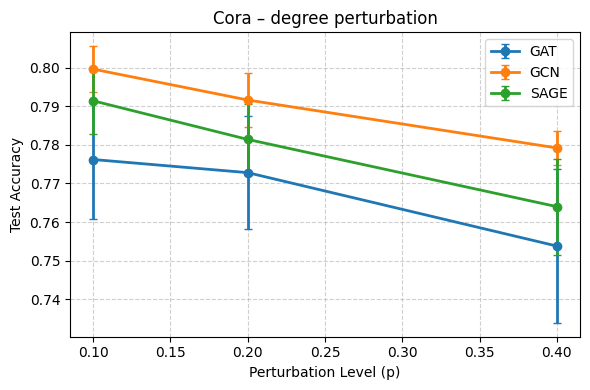

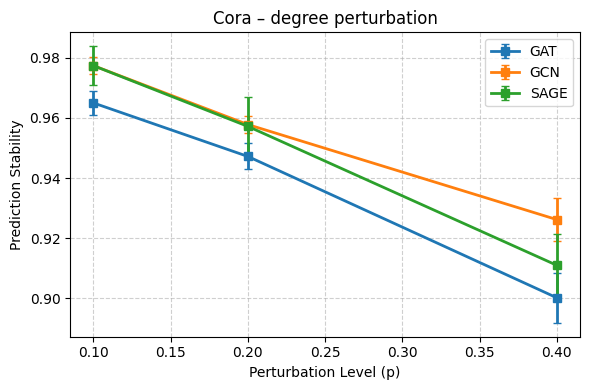

Generating plots for PubMed – random


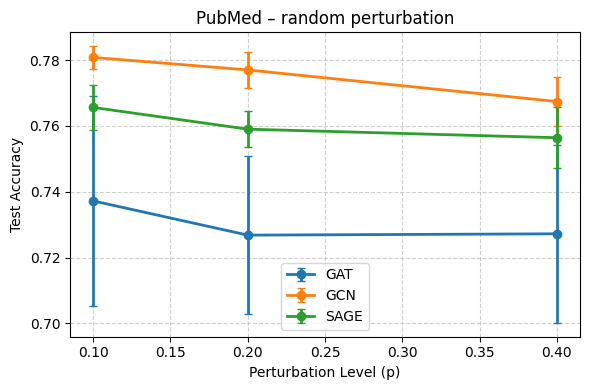

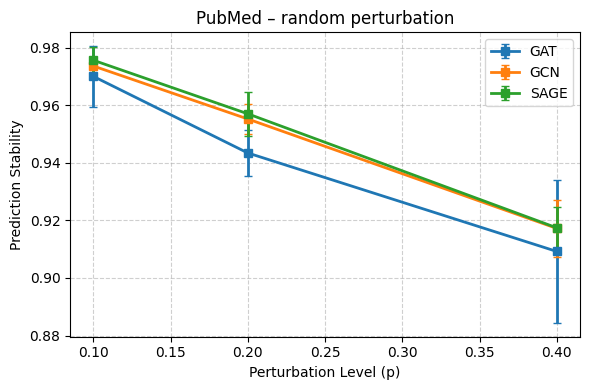

Generating plots for PubMed – degree


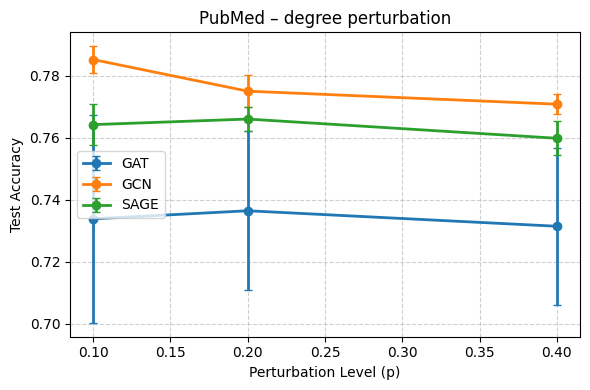

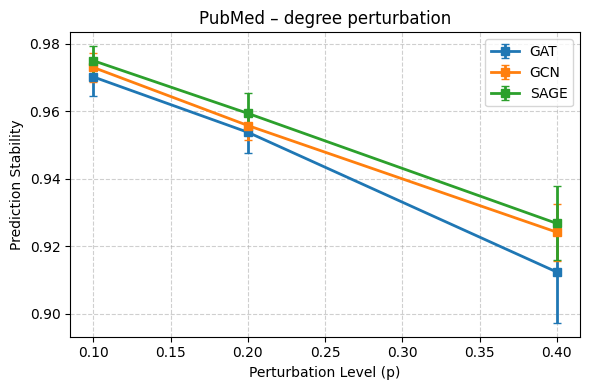

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# Load results.csv
# ------------------------
csv_path = "results.csv"
df = pd.read_csv(csv_path)

# ------------------------
# Compute mean ± std
# ------------------------
grouped = df.groupby(["dataset","model","perturbation","p"]).agg(
    acc_mean=("accuracy","mean"),
    acc_std=("accuracy","std"),
    stab_mean=("stability","mean"),
    stab_std=("stability","std")
).reset_index()

print("Datasets found:", grouped["dataset"].unique())
print("Perturbations found:", grouped["perturbation"].unique())

# ------------------------
# Plot Accuracy
# ------------------------
def plot_accuracy(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["acc_mean"], yerr=data_m["acc_std"],
            marker="o", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Test Accuracy")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"accuracy_{dataset_name}_{perturbation_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------
# Plot Stability
# ------------------------
def plot_stability(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["stab_mean"], yerr=data_m["stab_std"],
            marker="s", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Prediction Stability")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"stability_{dataset_name}_{perturbation_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------
# AUTO GENERATE FOR ALL DATASETS
# ------------------------
datasets = grouped["dataset"].unique()
perturbations = ["random", "degree"]

for d in datasets:
    for ptype in perturbations:
        print(f"Generating plots for {d} – {ptype}")
        plot_accuracy(d, ptype)
        plot_stability(d, ptype)


Datasets found: ['CiteSeer' 'Cora' 'PubMed']
Perturbations found: ['class' 'degree' 'random']
Generating plots for CiteSeer – random


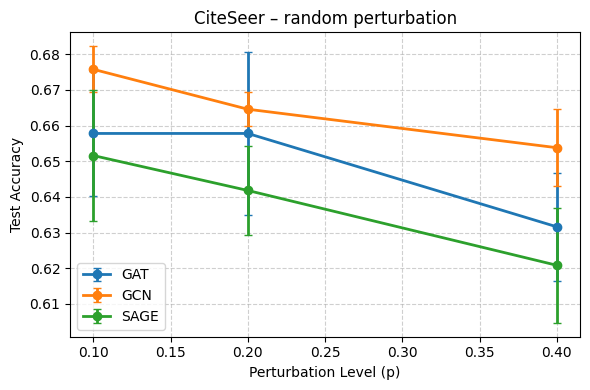

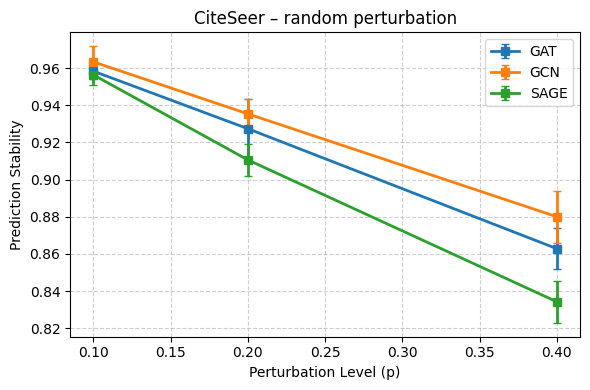

Generating plots for CiteSeer – degree


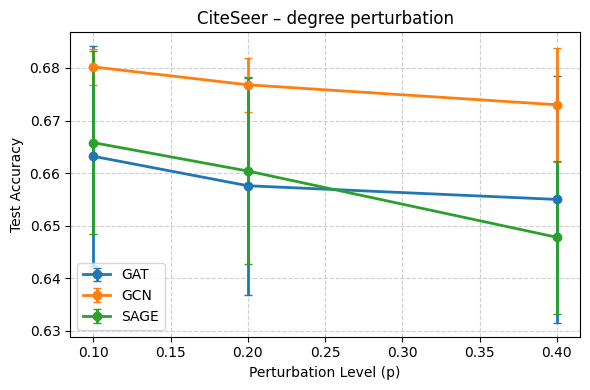

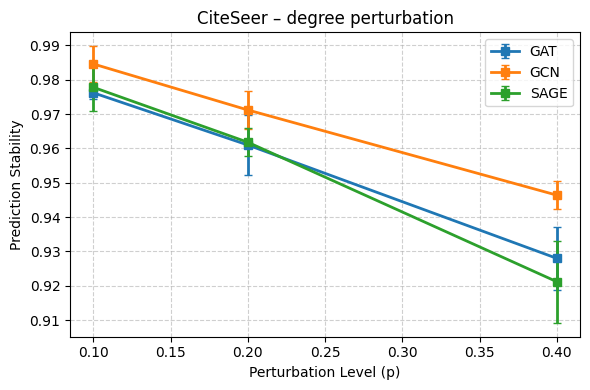

Generating plots for Cora – random


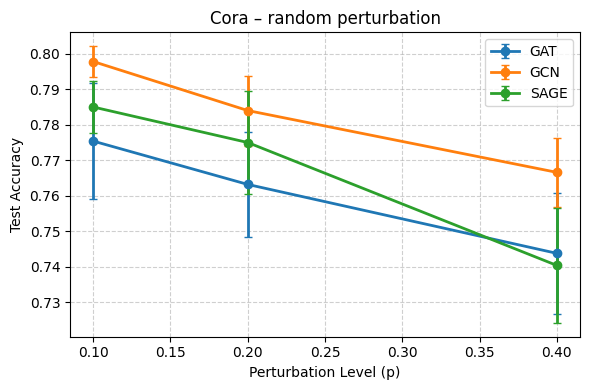

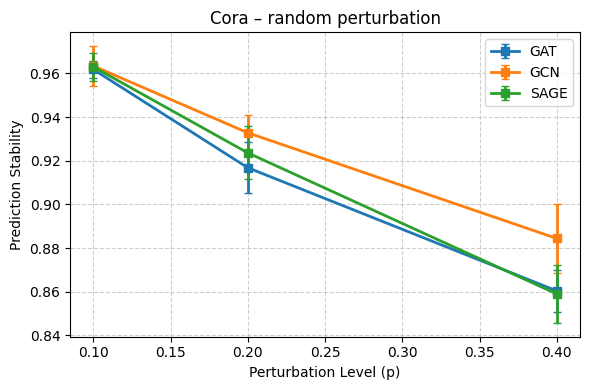

Generating plots for Cora – degree


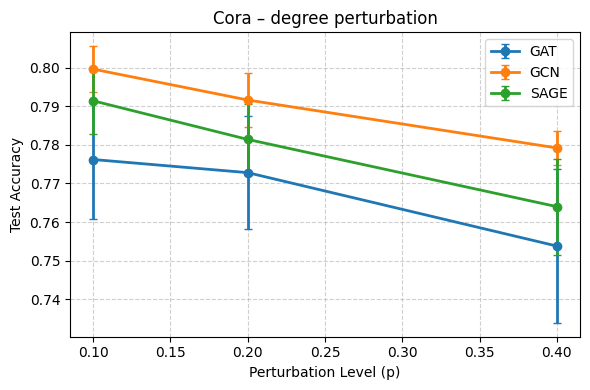

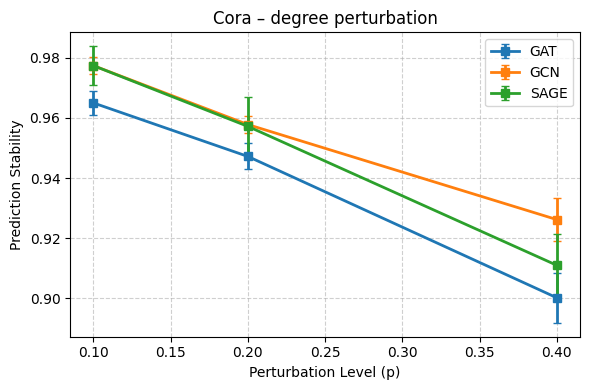

Generating plots for PubMed – random


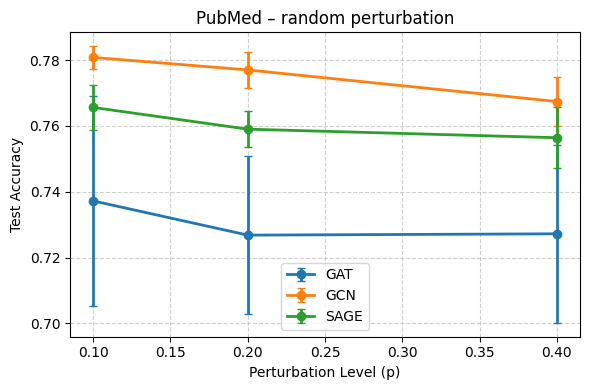

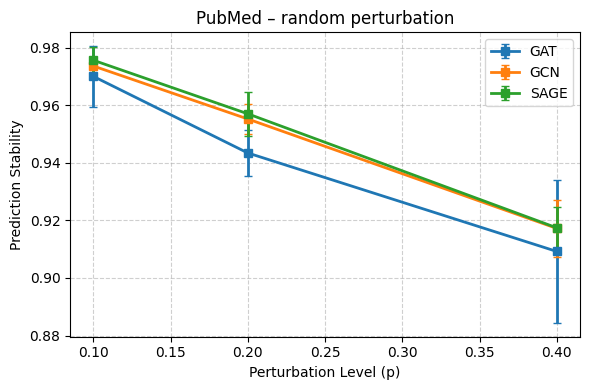

Generating plots for PubMed – degree


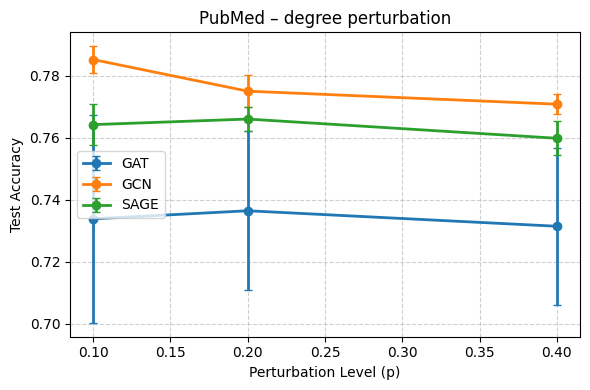

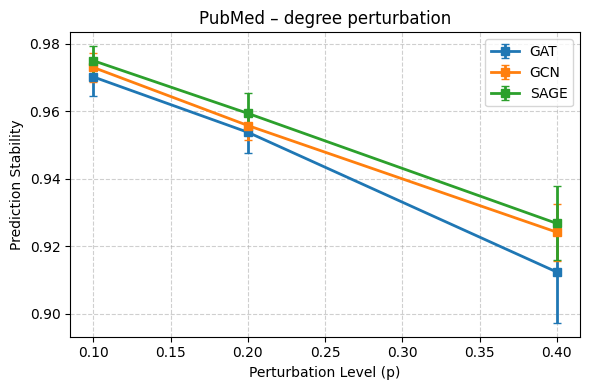

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------
# Load results.csv
# ------------------------
csv_path = "results.csv"
df = pd.read_csv(csv_path)

# ------------------------
# Compute mean ± std
# ------------------------
grouped = df.groupby(["dataset","model","perturbation","p"]).agg(
    acc_mean=("accuracy","mean"),
    acc_std=("accuracy","std"),
    stab_mean=("stability","mean"),
    stab_std=("stability","std")
).reset_index()

print("Datasets found:", grouped["dataset"].unique())
print("Perturbations found:", grouped["perturbation"].unique())

# ------------------------
# Plot Accuracy
# ------------------------
def plot_accuracy(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["acc_mean"], yerr=data_m["acc_std"],
            marker="o", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Test Accuracy")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"accuracy_{dataset_name}_{perturbation_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------
# Plot Stability
# ------------------------
def plot_stability(dataset_name, perturbation_type):
    subset = grouped[
        (grouped["dataset"] == dataset_name) &
        (grouped["perturbation"] == perturbation_type)
    ]

    plt.figure(figsize=(6,4))
    for model in subset["model"].unique():
        data_m = subset[subset["model"] == model]
        plt.errorbar(
            data_m["p"], data_m["stab_mean"], yerr=data_m["stab_std"],
            marker="s", capsize=3, linewidth=2, label=model
        )

    plt.xlabel("Perturbation Level (p)")
    plt.ylabel("Prediction Stability")
    plt.title(f"{dataset_name} – {perturbation_type} perturbation")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"stability_{dataset_name}_{perturbation_type}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------
# AUTO GENERATE FOR ALL DATASETS
# ------------------------
datasets = grouped["dataset"].unique()
perturbations = ["random", "degree"]

for d in datasets:
    for ptype in perturbations:
        print(f"Generating plots for {d} – {ptype}")
        plot_accuracy(d, ptype)
        plot_stability(d, ptype)


In [25]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed